# 🎯 Ederest — Edge Vision for On-Prem ERP
## Pipeline End-to-End : SAP Screenshot → JSON Ederest

**Pipeline :**
```
events.json + screenshots (snooping tool)
        ↓
YOLOv11s  → détection éléments UI
        ↓
EasyOCR   → extraction textes (labels + values)
        ↓
Post-processing → enrichissement par type d'élément
        ↓
JSON format Ederest (PracticeSession → PracticeField)
```

---
## Installation des dépendances

In [6]:
!pip install ultralytics easyocr -q
print('Dépendances installées !')

Dépendances installées !


---
## Imports

In [7]:
import os
import cv2
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import easyocr
from ultralytics import YOLO

print('Imports OK')

Imports OK


---
## Configuration

In [8]:
# ============================================================
# CHEMINS — à modifier selon ton Drive
# ============================================================
YOLO_MODEL_PATH = '/content/drive/MyDrive/ederest_v6_best.pt'
SCREENSHOTS_DIR = '/content/drive/MyDrive/PAbatchesfolder/test_pipeline/'
EVENTS_PATH     = '/content/drive/MyDrive/PAbatchesfolder/test_pipeline/events.json'
OUTPUT_JSON     = '/content/drive/MyDrive/PAbatchesfolder/test_pipeline/simulation_ederest.json'
SAVE_DIR        = '/content/drive/MyDrive/PAbatchesfolder/pipeline_outputs/'

# Créer les dossiers de sortie
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(f'{SAVE_DIR}/visualizations/', exist_ok=True)
os.makedirs(f'{SAVE_DIR}/yolo_outputs/', exist_ok=True)
os.makedirs(f'{SAVE_DIR}/jsons/', exist_ok=True)

# Classes YOLO
CLASSES = ['button', 'checkbox', 'dropdown', 'radio button', 'textbox', 'popup']

# Mapping YOLO → FieldType Ederest
TYPE_MAPPING = {
    'button'      : 'button',
    'textbox'     : 'text',
    'dropdown'    : 'dropdown',
    'checkbox'    : 'checkbox',
    'radio button': 'checkbox',
    'popup'       : 'button',
}

# Couleurs pour visualisation matplotlib
COLORS = {
    'button'      : '#FF6B6B',
    'checkbox'    : '#4ECDC4',
    'dropdown'    : '#45B7D1',
    'radio button': '#96CEB4',
    'textbox'     : '#FFEAA7',
    'popup'       : '#DDA0DD'
}

print('Configuration OK')
print(f'   YOLO model : {YOLO_MODEL_PATH}')
print(f'   Screenshots: {SCREENSHOTS_DIR}')
print(f'   Events     : {EVENTS_PATH}')
print(f'   Output     : {OUTPUT_JSON}')

Configuration OK
   YOLO model : /content/drive/MyDrive/ederest_v6_best.pt
   Screenshots: /content/drive/MyDrive/PAbatchesfolder/test_pipeline/
   Events     : /content/drive/MyDrive/PAbatchesfolder/test_pipeline/events.json
   Output     : /content/drive/MyDrive/PAbatchesfolder/test_pipeline/simulation_ederest.json


In [9]:
import os

# Chercher le modèle YOLO partout dans Drive
for root, dirs, files in os.walk('/content/drive/MyDrive/'):
    for file in files:
        if 'ederest' in file.lower() and file.endswith('.pt'):
            print(os.path.join(root, file))

/content/drive/MyDrive/ederest_v1_best.pt
/content/drive/MyDrive/ederest_v2_best.pt
/content/drive/MyDrive/ederest_v3_best.pt
/content/drive/MyDrive/ederest_v6_best.pt


---
## Chargement des modèles YOLO + EasyOCR

In [10]:
from google.colab import drive
drive.mount('/content/drive')

# Charger YOLO
yolo = YOLO(YOLO_MODEL_PATH)
print(f'YOLO chargé : {YOLO_MODEL_PATH}')

# Charger EasyOCR
reader = easyocr.Reader(['fr', 'en'], gpu=True)
print('EasyOCR chargé (fr + en, GPU)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


YOLO chargé : /content/drive/MyDrive/ederest_v6_best.pt
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR chargé (fr + en, GPU)


---
## Fonctions OCR

In [11]:
def ocr_full_screen(image_path):
    """
    Lance EasyOCR sur tout le screenshot.
    Retourne liste de blocs texte avec bbox, texte, confidence, center.
    """
    result      = reader.readtext(image_path)
    text_blocks = []

    for (bbox, text, confidence) in result:
        if confidence < 0.5:
            continue

        x1 = int(min(p[0] for p in bbox))
        y1 = int(min(p[1] for p in bbox))
        x2 = int(max(p[0] for p in bbox))
        y2 = int(max(p[1] for p in bbox))

        text_blocks.append({
            'text'      : text,
            'bbox'      : [x1, y1, x2, y2],
            'confidence': round(confidence, 3),
            'center'    : [(x1+x2)//2, (y1+y2)//2]
        })

    return text_blocks


def merge_nearby_text_blocks(text_blocks, max_gap=8):
    """
    Fusionne les blocs texte proches sur la même ligne.
    Utilisé UNIQUEMENT pour les labels (pas pour les values).
    max_gap=8 : gap max en pixels entre 2 blocs pour les fusionner.
    """
    if not text_blocks:
        return text_blocks

    sorted_blocks = sorted(text_blocks, key=lambda b: (b['center'][1], b['center'][0]))
    merged = []
    used   = set()

    for i, block in enumerate(sorted_blocks):
        if i in used:
            continue

        current_text = block['text']
        current_bbox = block['bbox'].copy()
        current_y    = block['center'][1]
        used.add(i)

        for j, other in enumerate(sorted_blocks):
            if j in used or j == i:
                continue

            other_y = other['center'][1]

            if abs(other_y - current_y) > 8:
                continue

            gap = other['bbox'][0] - current_bbox[2]
            if 0 <= gap <= max_gap:
                current_text    += ' ' + other['text']
                current_bbox[2]  = other['bbox'][2]
                current_bbox[3]  = max(current_bbox[3], other['bbox'][3])
                used.add(j)

        merged.append({
            'text'      : current_text,
            'bbox'      : current_bbox,
            'confidence': block['confidence'],
            'center'    : [(current_bbox[0]+current_bbox[2])//2,
                           (current_bbox[1]+current_bbox[3])//2]
        })

    return merged


print('Fonctions OCR définies')

Fonctions OCR définies


---
## Fonctions YOLO

In [12]:
def yolo_detect(image_path):
    """
    Détecte les éléments UI avec YOLOv11s.
    Retourne liste d'éléments avec type, bbox, confidence, center.
    """
    results    = yolo.predict(image_path, conf=0.3, verbose=False)
    detections = results[0].boxes
    elements   = []

    for box in detections:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        class_id        = int(box.cls[0])
        confidence      = float(box.conf[0])

        elements.append({
            'type'      : CLASSES[class_id],
            'bbox'      : [x1, y1, x2, y2],
            'confidence': round(confidence, 3),
            'center'    : [(x1+x2)//2, (y1+y2)//2],
            'label'     : '',
            'value'     : ''
        })

    return elements


def screens_are_similar(screen1_path, screen2_path, threshold=0.97):
    """
    Compare 2 screenshots.
    Si similarité > threshold → même layout → on peut réutiliser YOLO.
    """
    img1 = cv2.imread(screen1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(screen2_path, cv2.IMREAD_GRAYSCALE)

    img1 = cv2.resize(img1, (320, 240))
    img2 = cv2.resize(img2, (320, 240))

    diff       = cv2.absdiff(img1, img2)
    similarity = 1 - (np.sum(diff) / (img1.size * 255))

    return similarity > threshold


print('Fonctions YOLO définies')

Fonctions YOLO définies


---
## Fonctions Post-processing

In [13]:
def find_value(el, text_blocks):
    """
    Texte dont le CENTRE est strictement dans la bbox YOLO.
    Utilise text_blocks_raw (pas mergé) pour éviter de fusionner
    des textes de boutons adjacents (ex: Suite + Interrompre).
    """
    x1, y1, x2, y2 = el['bbox']
    inside = []
    for tb in text_blocks:
        tcx, tcy = tb['center']
        if x1 < tcx < x2 and y1 < tcy < y2:
            inside.append(tb['text'])
    return ' '.join(inside).strip()


def find_label(el, text_blocks):
    """
    Texte à GAUCHE sur la MÊME ligne — c'est le label du champ.
    Utilise text_blocks_merged pour avoir le label complet.
    Exclut explicitement tout texte en dessous de l'élément.
    """
    x1, y1, x2, y2 = el['bbox']
    el_height  = y2 - y1
    center_y   = (y1 + y2) / 2
    best_label = ''
    min_dist   = float('inf')

    for tb in text_blocks:
        tx1, ty1, tx2, ty2 = tb['bbox']
        tcx = (tx1 + tx2) / 2
        tcy = (ty1 + ty2) / 2

        is_left     = tcx < x1
        not_below   = tcy <= center_y + 5
        same_line   = abs(tcy - center_y) < el_height * 0.6
        not_too_far = (x1 - tcx) < 300

        if is_left and not_below and same_line and not_too_far:
            dist = x1 - tcx
            if dist < min_dist:
                min_dist   = dist
                best_label = tb['text']

    return best_label


def find_label_right(el, text_blocks):
    """
    Cherche uniquement le texte à DROITE sur la MÊME ligne.
    Exclut explicitement tout ce qui est en dessous.
    """
    x1, y1, x2, y2 = el['bbox']
    el_height  = y2 - y1
    center_y   = (y1 + y2) / 2
    best_label = ""
    min_dist   = float('inf')

    for tb in text_blocks:
        tx1, ty1, tx2, ty2 = tb['bbox']
        tcx = (tx1 + tx2) / 2
        tcy = (ty1 + ty2) / 2

        is_left     = tcx > x1                      # strictement à droite
        not_below   = tcy <= center_y + 5           # ← exclut ce qui est en dessous
        same_line   = abs(tcy - center_y) < el_height * 0.6  # même ligne proportionnelle
        not_too_far = (x1 - tcx) < 300              # pas trop loin

        if is_left and not_below and same_line and not_too_far:
            dist = x1 - tcx
            if dist < min_dist:
                min_dist   = dist
                best_label = tb['text']

    return best_label


def enrich_elements(yolo_elements, text_blocks_raw, text_blocks_merged):
    """
    Enrichit chaque élément YOLO avec label + value selon son type :
    - button       → value seulement  (raw)
    - textbox      → label (merged) + value (raw)
    - dropdown     → label (merged) + value (raw)
    - checkbox     → label (merged) seulement
    - radio button → label (merged) seulement
    - popup        → value (raw) seulement

    Pourquoi 2 listes ?
    → raw pour values : évite de merger 'Suite' + 'Interrompre' (2 boutons distincts)
    → merged pour labels : récupère 'Numéro de commande :' complet
    """
    for el in yolo_elements:
        t = el['type']

        if t == 'button':
            el['value'] = find_value(el, text_blocks_raw)
            el['label'] = ''

        elif t == 'textbox':
            el['label'] = find_label(el, text_blocks_merged)
            el['value'] = find_value(el, text_blocks_raw)

        elif t == 'dropdown':
            el['label'] = find_label(el, text_blocks_merged)
            el['value'] = find_value(el, text_blocks_raw)

        elif t in ['checkbox', 'radio button']:
            el['label'] = find_label(el, text_blocks_merged)  # ← mergé
            el['value'] = ""
            if not (el['label']):
                el['label'] = find_label_right(el, text_blocks_merged)

        elif t == 'popup':
            el['value'] = find_value(el, text_blocks_raw)
            el['label'] = ''

    return yolo_elements


def filter_elements_in_popup(elements):
    """
    Si un popup est détecté → garder seulement les éléments
    à l'intérieur du popup. Ignore les éléments de l'écran derrière.
    """
    popups = [el for el in elements if el['type'] == 'popup']

    if not popups:
        return elements

    popup = max(popups, key=lambda p:
                (p['bbox'][2]-p['bbox'][0]) * (p['bbox'][3]-p['bbox'][1]))

    px1, py1, px2, py2 = popup['bbox']

    filtered = [popup]
    for el in elements:
        if el['type'] == 'popup':
            continue
        cx, cy = el['center']
        if px1 <= cx <= px2 and py1 <= cy <= py2:
            filtered.append(el)

    return filtered


print('Fonctions post-processing définies')

Fonctions post-processing définies


---
## Fonctions Visualisation + Sauvegarde

In [14]:
def visualize(image_path, elements, save=True):
    """Affiche + sauvegarde le screenshot avec les bounding boxes."""
    img = Image.open(image_path).convert('RGB')
    fig, ax = plt.subplots(1, 1, figsize=(18, 10))
    ax.imshow(img)

    for el in elements:
        x1, y1, x2, y2 = el['bbox']
        color = COLORS.get(el['type'], '#FFFFFF')

        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color,
            facecolor=color, alpha=0.25
        )
        ax.add_patch(rect)

        display_text = el['value'] if el['value'] else el['label']
        display_text = f"[{el['type']}] {display_text[:20]}"

        ax.text(x1, y1-5, display_text, fontsize=7, color='white',
                bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor='none'))

    ax.axis('off')
    ax.set_title(image_path.split('/')[-1], fontsize=10)
    plt.tight_layout()

    if save:
        screen_name = image_path.split('/')[-1].replace('.png','').replace('.jpg','')
        out_path    = f"{SAVE_DIR}/visualizations/{screen_name}_viz.png"
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f" Visualisation sauvegardée : {out_path}")

    plt.show()
    plt.close()


def save_yolo_visualization(image_path, elements):
    """Sauvegarde screenshot avec bounding boxes YOLO (OpenCV)."""
    img = cv2.imread(image_path)

    COLORS_BGR = {
        'button'      : (0, 0, 255),
        'checkbox'    : (255, 200, 0),
        'dropdown'    : (255, 165, 0),
        'radio button': (0, 255, 0),
        'textbox'     : (0, 255, 255),
        'popup'       : (255, 0, 255),
    }

    for el in elements:
        x1, y1, x2, y2 = el['bbox']
        color   = COLORS_BGR.get(el['type'], (255, 255, 255))
        display = f"[{el['type']}] {(el['value'] or el['label'])[:15]}"

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.rectangle(img, (x1, y1-20), (x1+len(display)*7, y1), color, -1)
        cv2.putText(img, display, (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,255), 1)

    screen_name = image_path.split('/')[-1].replace('.png','').replace('.jpg','')
    out_path    = f"{SAVE_DIR}/yolo_outputs/{screen_name}_yolo.jpg"
    cv2.imwrite(out_path, img)
    print(f" YOLO output sauvegardé : {out_path}")
    return out_path


def visualize_clicked(image_path, all_elements, clicked_element, step_num):
    """Affiche le screenshot avec l'élément cliqué surligné en rouge."""
    img = Image.open(image_path).convert('RGB')
    fig, ax = plt.subplots(1, 1, figsize=(16, 9))
    ax.imshow(img)

    for el in all_elements:
        x1, y1, x2, y2 = el['bbox']
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=1, edgecolor='gray',
            facecolor='gray', alpha=0.1
        )
        ax.add_patch(rect)

    if clicked_element:
        x1, y1, x2, y2 = clicked_element['bbox']
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=3, edgecolor='red',
            facecolor='red', alpha=0.3
        )
        ax.add_patch(rect)

        label = clicked_element['label'] or clicked_element['value'] or clicked_element['type']
        ax.text(x1, y1-8, f" CLIQUÉ: [{clicked_element['type']}] {label}",
                fontsize=9, color='white',
                bbox=dict(facecolor='red', alpha=0.9, pad=2, edgecolor='none'))

    ax.axis('off')
    ax.set_title(f"Step {step_num} — {image_path.split('/')[-1]}", fontsize=10)
    plt.tight_layout()

    screen_name = image_path.split('/')[-1].replace('.png','').replace('.jpg','')
    out_path    = f"{SAVE_DIR}/visualizations/{screen_name}_step{step_num}_clicked.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f" Visualisation cliqué sauvegardée : {out_path}")


print('Fonctions visualisation définies')

Fonctions visualisation définies


---
## Pipeline principal (analyze_screenshot_smart)

In [15]:
def analyze_screenshot_smart(image_path, prev_image_path=None,
                              cached_elements=None, show_viz=False, save=True):
    """
    Pipeline complet YOLO + OCR avec cache.

    Optimisation cache YOLO :
    Si le layout est similaire au screen précédent (similarity > 0.97)
    → réutilise les détections YOLO (économise ~180ms)
    → relance toujours OCR (le texte peut avoir changé)
    """
    print(f"\n🖼️  Analyse : {image_path.split('/')[-1]}")

    # 1. OCR toujours lancé
    text_blocks_raw    = ocr_full_screen(image_path)
    text_blocks_merged = merge_nearby_text_blocks(text_blocks_raw, max_gap=8)
    print(f" OCR : {len(text_blocks_raw)} blocs bruts → {len(text_blocks_merged)} blocs mergés")

    # 2. YOLO : cache ou relance
    if (prev_image_path is not None and
        cached_elements is not None and
        screens_are_similar(prev_image_path, image_path)):
        print(f"  YOLO skippé — layout similaire, cache réutilisé")
        elements = cached_elements
    else:
        print(f"  YOLO lancé — nouveau layout détecté")
        elements = yolo_detect(image_path)
        print(f"  YOLO : {len(elements)} éléments détectés")

    # 3. Enrichir avec OCR
    elements = enrich_elements(elements, text_blocks_raw, text_blocks_merged)

    # 4. Filtrer popup
    elements = filter_elements_in_popup(elements)

    # 5. Filtrer low confidence
    elements = [el for el in elements if el['confidence'] >= 0.45]

    # 6. Affichage tableau
    print(f"\n   {'Type':<15} {'Label':<30} {'Value':<25} {'Conf'}")
    print(f"   {'-'*80}")
    for el in elements:
        print(f"   {el['type']:<15} {el['label']:<30} {el['value']:<25} {el['confidence']}")

    # 7. Sauvegardes
    if save:
        save_yolo_visualization(image_path, elements)
        screen_name = image_path.split('/')[-1].replace('.png','').replace('.jpg','')
        json_out    = f"{SAVE_DIR}/jsons/{screen_name}_elements.json"
        with open(json_out, 'w', encoding='utf-8') as f:
            json.dump(elements, f, ensure_ascii=False, indent=2)
        print(f" Elements JSON sauvegardé : {json_out}")

    # 8. Visualisation
    if show_viz:
        visualize(image_path, elements, save=save)

    return elements, text_blocks_raw, text_blocks_merged


print('analyze_screenshot_smart défini')

analyze_screenshot_smart défini


---
## Génération JSON Ederest

In [16]:
def bbox_to_percent(bbox, img_width, img_height):
    """Convertit une bbox pixels → pourcentages (format Ederest FieldPosition)."""
    x1, y1, x2, y2 = bbox
    return {
        'x'            : round((x1 / img_width)        * 100, 2),
        'y'            : round((y1 / img_height)       * 100, 2),
        'width'        : round(((x2-x1) / img_width)   * 100, 2),
        'height'       : round(((y2-y1) / img_height)  * 100, 2),
        'canvas_width' : img_width,
        'canvas_height': img_height
    }


def find_clicked_element(elements, click_x, click_y):
    """Trouve l'élément le plus proche des coordonnées du clic."""
    closest  = None
    min_dist = float('inf')

    for el in elements:
        cx, cy = el['center']
        dist   = ((cx - click_x)**2 + (cy - click_y)**2) ** 0.5
        if dist < min_dist:
            min_dist = dist
            closest  = el

    return closest


def find_same_element(original_el, next_elements):
    """
    Retrouve le même textbox sur le screen suivant.
    Utilisé pour lire la valeur saisie par l'utilisateur.
    """
    ox1, oy1, ox2, oy2 = original_el['bbox']
    o_center_x = (ox1 + ox2) / 2
    o_center_y = (oy1 + oy2) / 2

    best     = None
    min_dist = float('inf')

    for el in next_elements:
        if el['type'] != 'textbox':
            continue
        if el['label'] != original_el['label']:
            continue

        cx, cy = el['center']
        dist   = ((cx - o_center_x)**2 + (cy - o_center_y)**2) ** 0.5

        if dist < min_dist and dist < 50:
            min_dist = dist
            best     = el

    return best


def generate_steps(events, screenshots_dir):
    """
    Génère la liste des InteractiveImages au format Ederest.

    Pour chaque event :
    - 1 step CLICK : l'élément sur lequel l'utilisateur a cliqué
    - 1 step TYPE  : si c'est un textbox → valeur lue sur le screen suivant
    """
    interactive_images = []
    prev_elements      = None
    prev_screen        = None

    for i, event in enumerate(events):
        current_screen = os.path.join(screenshots_dir, event['screenshot'])

        print(f"\n{'='*60}")
        print(f"Event {event['step']} — clic à ({event['x']}, {event['y']})")

        # YOLO + OCR avec cache
        elements, tb_raw, tb_merged = analyze_screenshot_smart(
            current_screen,
            prev_image_path = prev_screen,
            cached_elements = prev_elements,
            show_viz        = False,
            save            = True
        )

        # Trouver l'élément cliqué
        clicked = find_clicked_element(elements, event['x'], event['y'])

        if clicked is None:
            print(f"  Aucun élément trouvé près du clic")
            prev_screen   = current_screen
            prev_elements = elements
            continue

        print(f" Élément cliqué : [{clicked['type']}] label='{clicked['label']}' value='{clicked['value']}'")

        # Dimensions image
        img              = cv2.imread(current_screen)
        img_h, img_w     = img.shape[:2]
        position         = bbox_to_percent(clicked['bbox'], img_w, img_h)

        # Visualisation cliqué
        visualize_clicked(current_screen, elements, clicked, event['step'])

        name        = clicked['label'] or clicked['value'] or clicked['type']
        field_type  = TYPE_MAPPING.get(clicked['type'], 'button')
        instruction = f"Cliquez sur {clicked['value'] or clicked['label'] or clicked['type']}"

        # ── STEP CLICK ──
        interactive_images.append({
            'image_id'          : f'step_{i}_click',
            'sequence'          : len(interactive_images),
            'image'             : event['screenshot'],
            'instruction'       : instruction,
            'screenshot_width'  : img_w,
            'screenshot_height' : img_h,
            'fields'            : [{
                'field_id'  : f'step_{i}_field_click',
                'name'      : name,
                'field_type': field_type,
                'active'    : True,
                'required'  : True,
                'colored'   : True,
                'order'     : 0,
                'position'  : position,
                'field_data': {
                    'description'    : clicked['label'] or '',
                    'instruction'    : instruction,
                    'check_response' : False,
                    'correct_answers': [],
                    'show_placeholder': True
                }
            }]
        })

        # ── STEP TYPE (seulement pour textbox + screen suivant disponible) ──
        if clicked['type'] == 'textbox' and i + 1 < len(events):
            next_screen_path = os.path.join(
                screenshots_dir, events[i+1]['screenshot']
            )

            next_elements, _, _ = analyze_screenshot_smart(
                next_screen_path,
                prev_image_path = current_screen,
                cached_elements = elements,
                show_viz        = False,
                save            = False
            )

            same_textbox = find_same_element(clicked, next_elements)

            if same_textbox and same_textbox['value']:
                next_img         = cv2.imread(next_screen_path)
                next_h, next_w   = next_img.shape[:2]
                next_position    = bbox_to_percent(same_textbox['bbox'], next_w, next_h)
                type_instruction = f"Tapez {same_textbox['value']}"

                print(f"   📝 Type step généré : '{same_textbox['value']}'")

                interactive_images.append({
                    'image_id'          : f'step_{i}_type',
                    'sequence'          : len(interactive_images),
                    'image'             : events[i+1]['screenshot'],
                    'instruction'       : f"Tapez {same_textbox['value']} dans {clicked['label']}",
                    'screenshot_width'  : next_w,
                    'screenshot_height' : next_h,
                    'fields'            : [{
                        'field_id'  : f'step_{i}_field_type',
                        'name'      : clicked['label'],
                        'field_type': 'text',
                        'active'    : True,
                        'required'  : True,
                        'colored'   : True,
                        'order'     : 0,
                        'position'  : next_position,
                        'field_data': {
                            'description'    : clicked['label'],
                            'instruction'    : type_instruction,
                            'check_response' : True,
                            'correct_answers': [same_textbox['value']],
                            'show_placeholder': True
                        }
                    }]
                })

        prev_screen   = current_screen
        prev_elements = elements

    return interactive_images


def generate_ederest_json_final(events_path, screenshots_dir, output_path):
    """Fonction principale — génère le JSON Ederest complet."""

    with open(events_path, 'r', encoding='utf-8') as f:
        events = json.load(f)

    print(f" {len(events)} events chargés depuis {events_path}")

    interactive_images = generate_steps(events, screenshots_dir)

    result = {
        'title'            : 'Simulation SAP',
        'platform'         : 'SAP',
        'language'         : 'fr',
        'formation_type'   : 'TUTORIAL',
        'difficulty'       : 'beginner',
        'total_step_count' : len(interactive_images),
        'total_image_count': len(interactive_images),
        'collections'      : [{
            'collection_id'     : 'collection_1',
            'collection_type'   : 'interactive',
            'sequence'          : 0,
            'required'          : True,
            'interactive_images': interactive_images
        }]
    }

    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(result, f, ensure_ascii=False, indent=2)

    import shutil
    shutil.copy(output_path, f"{SAVE_DIR}/jsons/simulation_ederest_final.json")

    print(f"\n{'='*60}")
    print(f"JSON Ederest généré !")
    print(f"   {len(interactive_images)} steps générés")
    print(f"   Sauvegardé : {output_path}")

    return result


print('Fonctions génération JSON définies')

Fonctions génération JSON définies


---
## TEST sur quelques screens (visualisation)


🖼️  Analyse : b4_014_Création_Contrat_Cré_image_2025-05-18_100924452_9a36263576ab4659b15181d7ff26911d.png


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


 OCR : 49 blocs bruts → 42 blocs mergés
  YOLO lancé — nouveau layout détecté
  YOLO : 39 éléments détectés

   Type            Label                          Value                     Conf
   --------------------------------------------------------------------------------
   textbox         Crs:                                                     0.912
   textbox         Contrat:                                                 0.903
   textbox         Foumisseur: 60001268           60001268                  0.902
   textbox         Groupe dacheteurs: K2O         K2O                       0.902
   textbox         Jours                                                    0.902
   textbox         Organisation achats: PKOI      PKOI                      0.9
   textbox         Paiement dans:                                           0.9
   textbox         Val. cible                     MAD                       0.897
   textbox         Jours                                                  

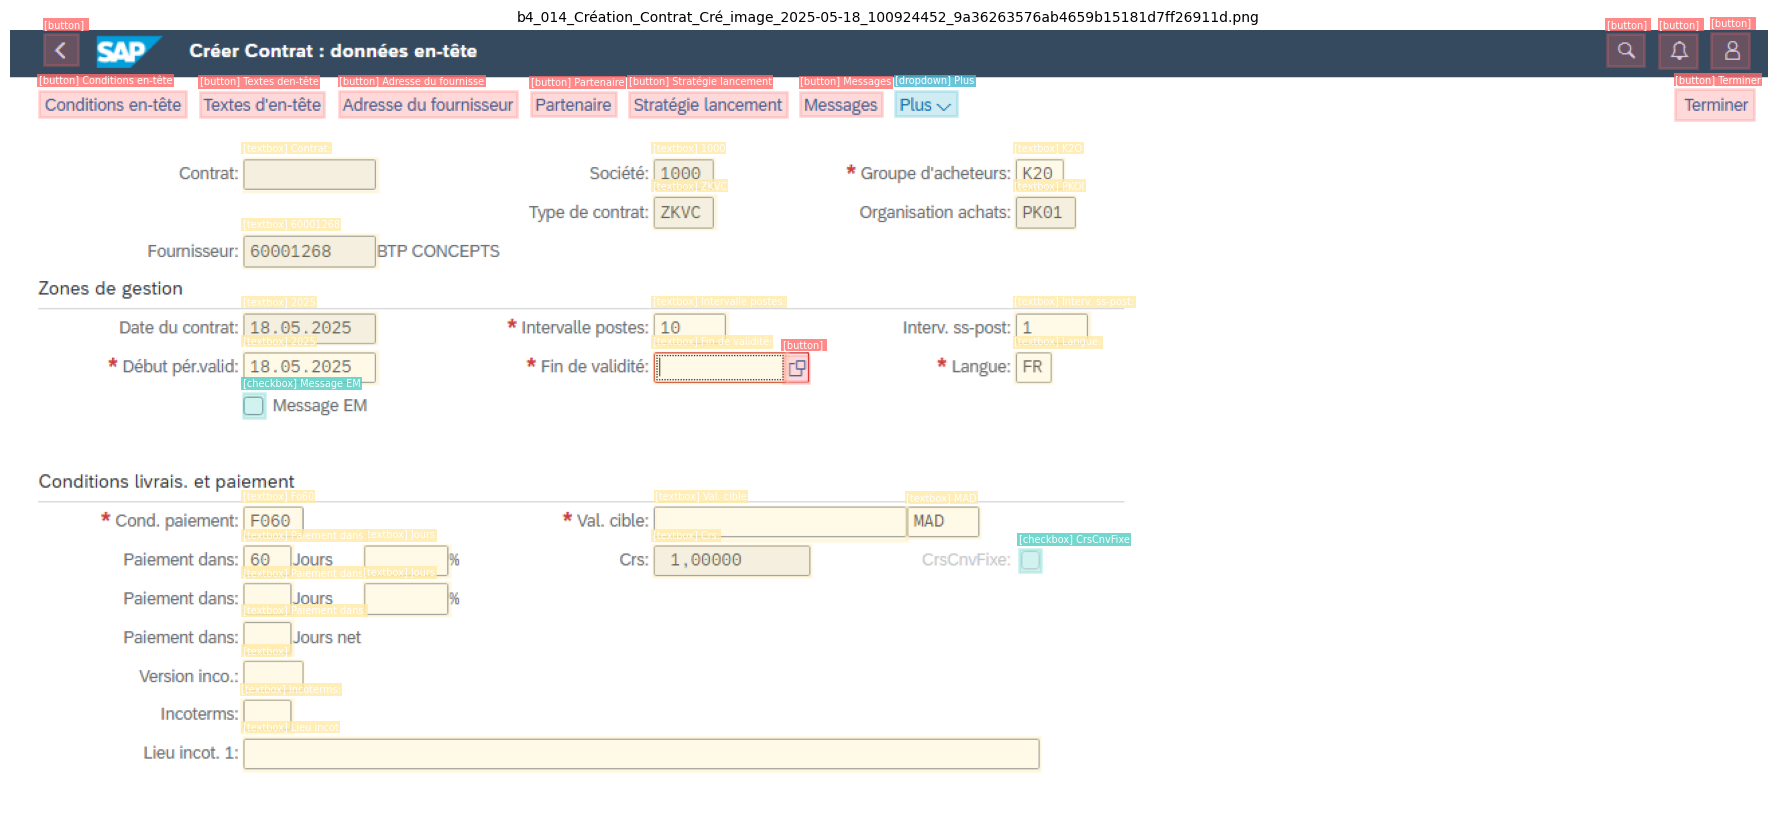


🖼️  Analyse : b4_018_Création_Contrat_Cré_image_2025-05-18_101820936_6f9fd47f7a5945189097f0c7ca52f236.png


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


 OCR : 55 blocs bruts → 48 blocs mergés
  YOLO skippé — layout similaire, cache réutilisé

   Type            Label                          Value                     Conf
   --------------------------------------------------------------------------------
   textbox         Crs:                                                     0.912
   textbox         Contrat:                                                 0.903
   textbox         Foumisseur: 60001268           60001268                  0.902
   textbox         Groupe dacheteurs:                                       0.902
   textbox         Jours                                                    0.902
   textbox         Organisation achats: PKOI      PKOI                      0.9
   textbox         Paiement dans:                                           0.9
   textbox         000 . 000                      MAD                       0.897
   textbox         Jours                                                    0.896
   textbox

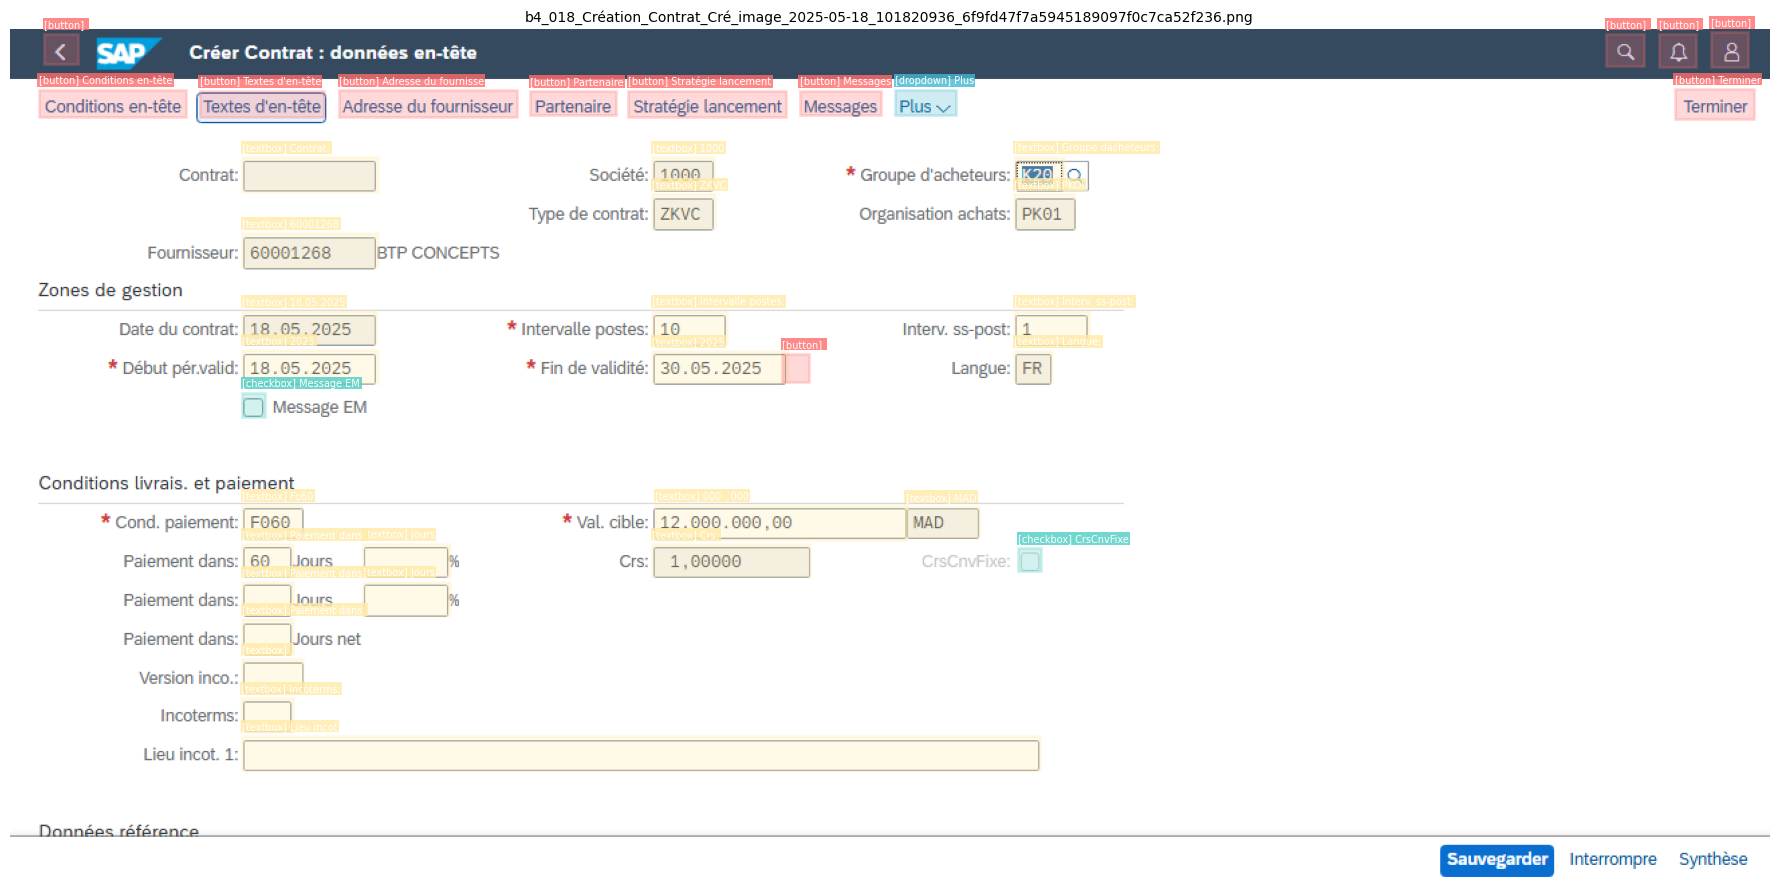

In [17]:
# Test rapide sur 2-3 screens pour vérifier le pipeline
test_screens = [
    '/content/drive/MyDrive/PAbatchesfolder/test_pipeline_3/b4_014_Création_Contrat_Cré_image_2025-05-18_100924452_9a36263576ab4659b15181d7ff26911d.png',
    '/content/drive/MyDrive/PAbatchesfolder/test_pipeline_3/b4_018_Création_Contrat_Cré_image_2025-05-18_101820936_6f9fd47f7a5945189097f0c7ca52f236.png',
]

prev_path     = None
prev_elements = None

for screen in test_screens:
    elements, tb_raw, tb_merged = analyze_screenshot_smart(
        screen,
        prev_image_path = prev_path,
        cached_elements = prev_elements,
        show_viz        = True,
        save            = True
    )
    prev_path     = screen
    prev_elements = elements

---
## RUN PIPELINE COMPLET

 4 events chargés depuis /content/drive/MyDrive/PAbatchesfolder/test_pipeline/events.json

Event 1 — clic à (516, 268)

🖼️  Analyse : b4_044_Création_d_article_C_Article_28_FZE_Img2_533805c259574870921243884e20838a.png


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


 OCR : 15 blocs bruts → 15 blocs mergés
  YOLO lancé — nouveau layout détecté
  YOLO : 18 éléments détectés

   Type            Label                          Value                     Conf
   --------------------------------------------------------------------------------
   textbox                                                                  0.895
   button                                         Terminer                  0.861
   button                                         Sunte                     0.86
   dropdown        Type jaruicle:                                           0.86
   dropdown        Branche                                                  0.851
   textbox         Article:                                                 0.844
   textbox                                                                  0.839
   button                                         Sélection des vues        0.838
   textbox         Bravo                                                

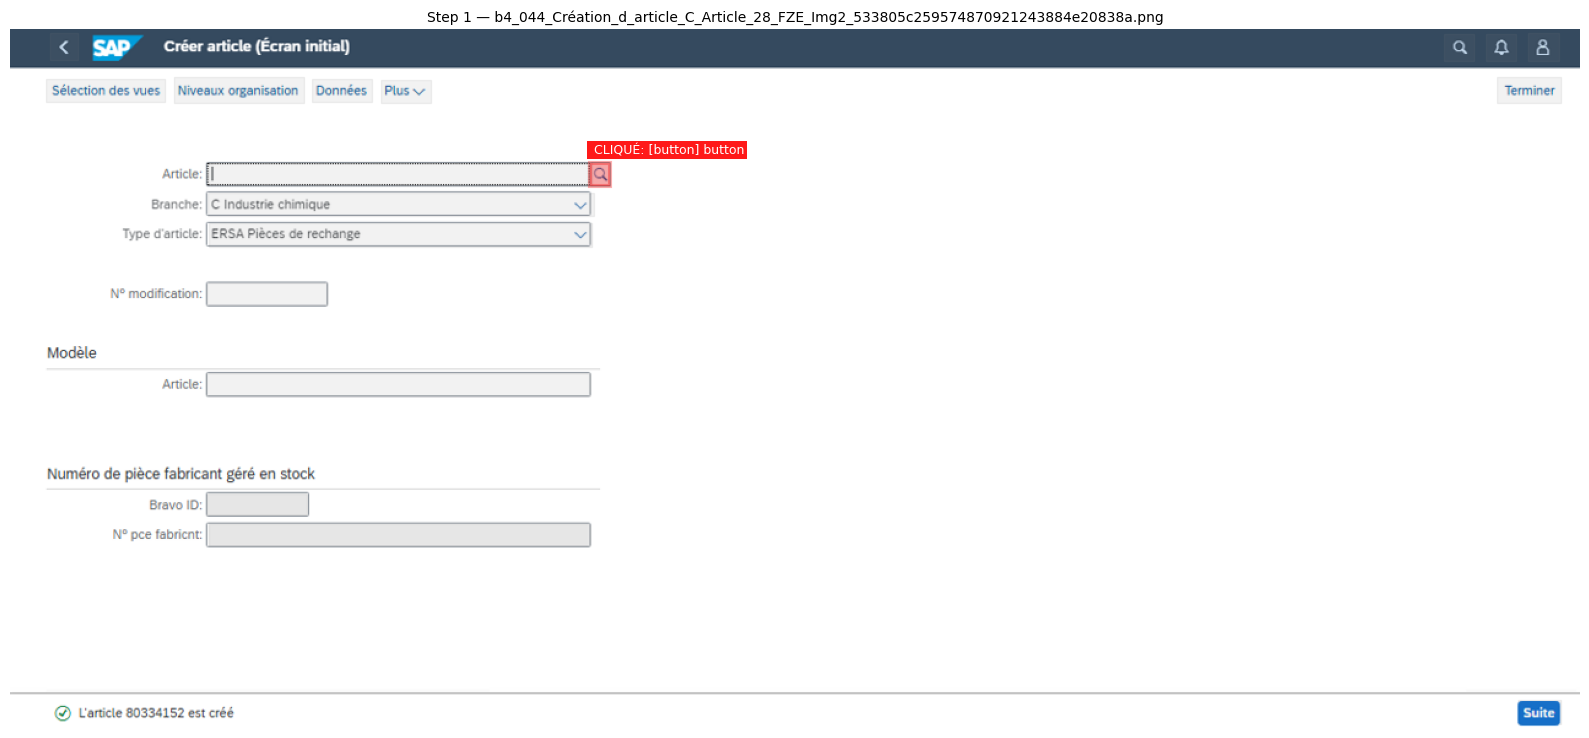

 Visualisation cliqué sauvegardée : /content/drive/MyDrive/PAbatchesfolder/pipeline_outputs//visualizations/b4_044_Création_d_article_C_Article_28_FZE_Img2_533805c259574870921243884e20838a_step1_clicked.png

Event 2 — clic à (462, 96)

🖼️  Analyse : b4_045_Création_d_article_C_Article_2_FZE_Img2_e14a479c6db34e49a48b645be4b04cfe.png


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


 OCR : 32 blocs bruts → 31 blocs mergés
  YOLO lancé — nouveau layout détecté
  YOLO : 46 éléments détectés

   Type            Label                          Value                     Conf
   --------------------------------------------------------------------------------
   popup                                          Sélection des vues Vue Gestion emplacements magasin 1 Gestion emplacements magasin  Monogement qualte Comptabilité Comptabilité exécution Données valorisation segment Select des vues uniquement sur demande CreervuesMarouees Niveaux organisation Données 8Paramétrage 0.947
   button                                         Données                   0.853
   button                                                                   0.828
   button                                         8Paramétrage              0.824
   button                                                                   0.812
   button                                         Niveaux organisation      

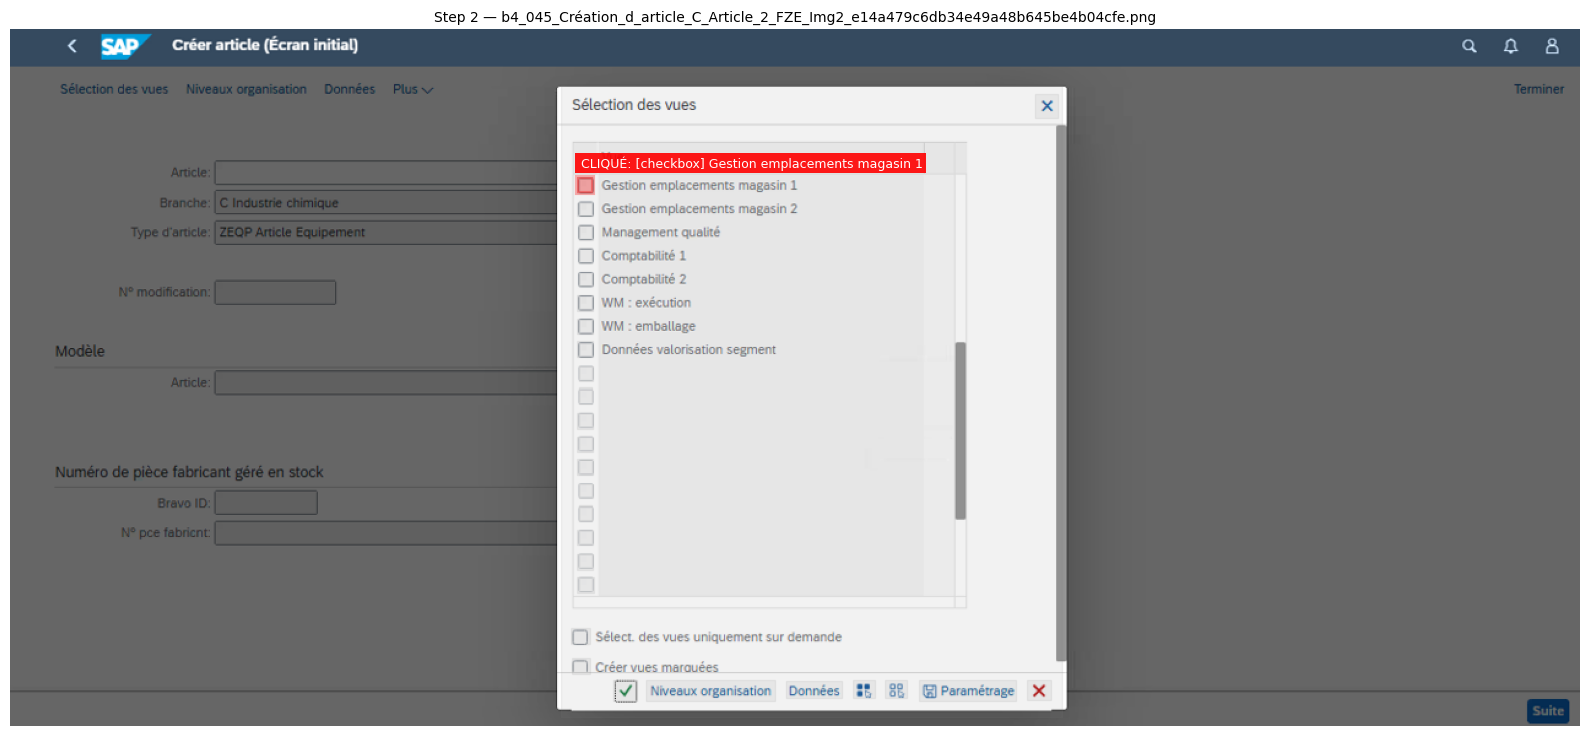

 Visualisation cliqué sauvegardée : /content/drive/MyDrive/PAbatchesfolder/pipeline_outputs//visualizations/b4_045_Création_d_article_C_Article_2_FZE_Img2_e14a479c6db34e49a48b645be4b04cfe_step2_clicked.png

Event 3 — clic à (500, 539)

🖼️  Analyse : b4_046_Création_d_article_C_Article_2_FZE_Img_20b99b9b6bff4d0f85923e6fa40e4731.png


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


 OCR : 38 blocs bruts → 36 blocs mergés
  YOLO lancé — nouveau layout détecté
  YOLO : 45 éléments détectés

   Type            Label                          Value                     Conf
   --------------------------------------------------------------------------------
   popup                                          Sélection des vues Vue Classification Donnees Qe base SPPetenques Achats Importations Texte de commande dachat Plenification des besoins Plenification des besoins Plenification des Plenification des besoins Plenification étendue Previsions Préparation du travail Données gén. divis {stockage Données gén. divis Istockage Gesuon emplacements magasin 1 Sélect Oes vues uniquement sur demande Creer vues Marouees Niveaux organisation Données Paramérrage 0.948
   button                                         Niveaux organisation      0.809
   button                                         Paramérrage               0.779
   button                                         Donné

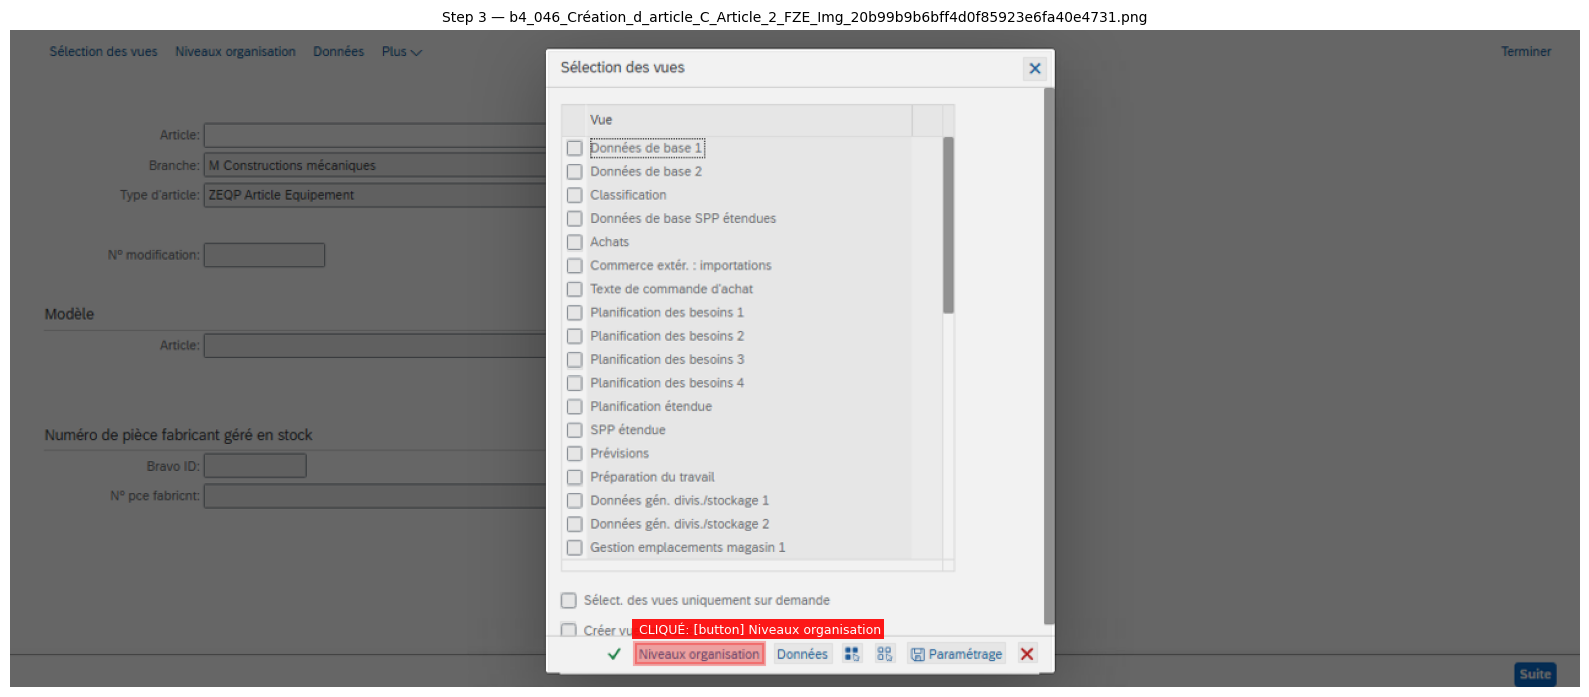

 Visualisation cliqué sauvegardée : /content/drive/MyDrive/PAbatchesfolder/pipeline_outputs//visualizations/b4_046_Création_d_article_C_Article_2_FZE_Img_20b99b9b6bff4d0f85923e6fa40e4731_step3_clicked.png

Event 4 — clic à (1238, 557)

🖼️  Analyse : b4_047_Création_d_article_C_Article_3_FZE_Img_150ab1c955fe4d1c84923f3c93d2fa4b.png


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


 OCR : 24 blocs bruts → 22 blocs mergés
  YOLO lancé — nouveau layout détecté
  YOLO : 27 éléments détectés

   Type            Label                          Value                     Conf
   --------------------------------------------------------------------------------
   popup                                          Nvx organisationnels Nvx organisationnels Division; emande Selection des vues Paramétrage 0.933
   textbox                                                                  0.824
   textbox         Division;                                                0.814
   button                                         Paramétrage               0.811
   button                                         Selection des vues        0.776
   button                                                                   0.747
   button                                                                   0.741
   checkbox        emande                                                   0.739
   but

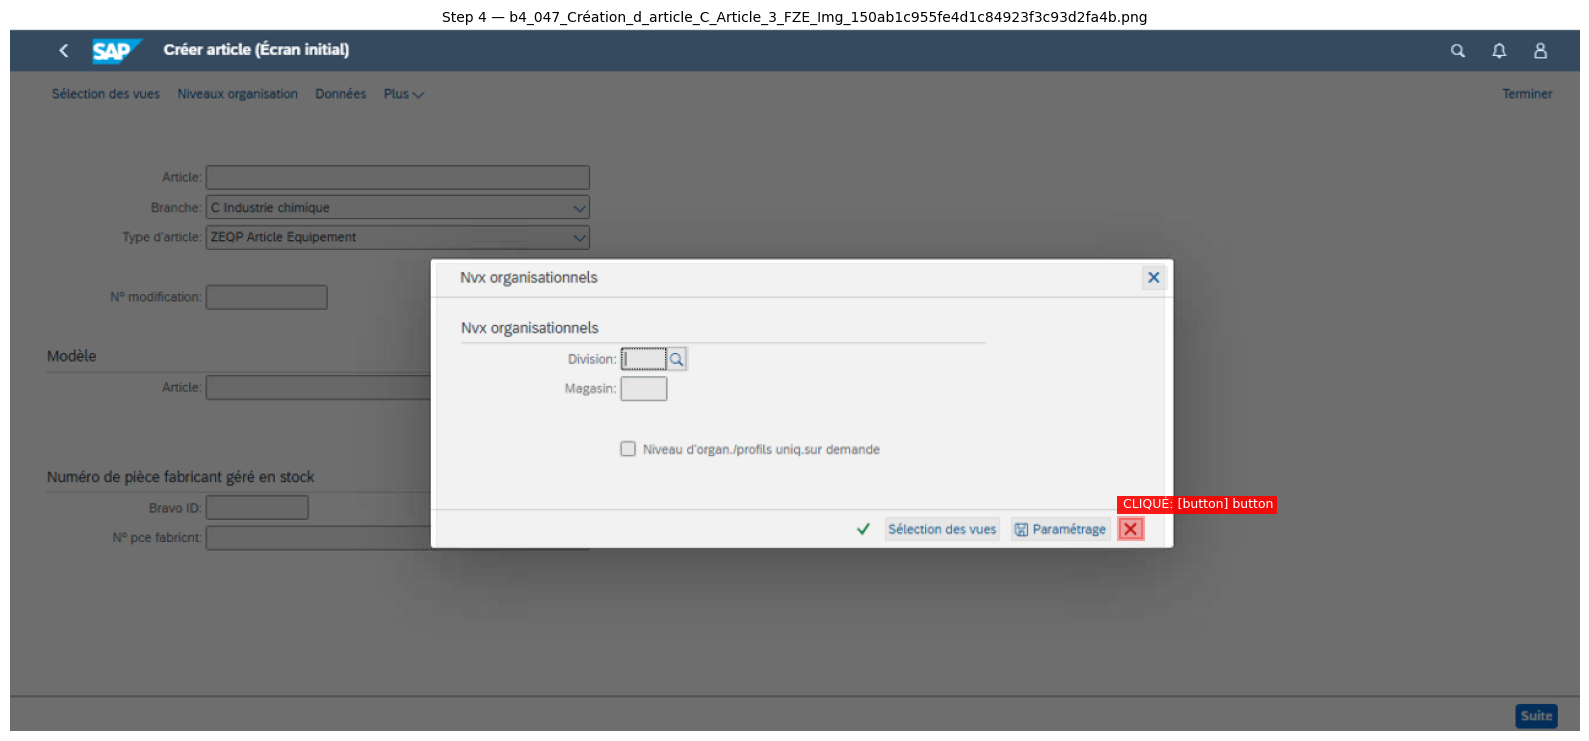

 Visualisation cliqué sauvegardée : /content/drive/MyDrive/PAbatchesfolder/pipeline_outputs//visualizations/b4_047_Création_d_article_C_Article_3_FZE_Img_150ab1c955fe4d1c84923f3c93d2fa4b_step4_clicked.png

JSON Ederest généré !
   4 steps générés
   Sauvegardé : /content/drive/MyDrive/PAbatchesfolder/test_pipeline/simulation_ederest.json

 JSON Ederest généré :
{
  "title": "Simulation SAP",
  "platform": "SAP",
  "language": "fr",
  "formation_type": "TUTORIAL",
  "difficulty": "beginner",
  "total_step_count": 4,
  "total_image_count": 4,
  "collections": [
    {
      "collection_id": "collection_1",
      "collection_type": "interactive",
      "sequence": 0,
      "required": true,
      "interactive_images": [
        {
          "image_id": "step_0_click",
          "sequence": 0,
          "image": "b4_044_Création_d_article_C_Article_28_FZE_Img2_533805c259574870921243884e20838a.png",
          "instruction": "Cliquez sur button",
          "screenshot_width": 1280,
          "

In [18]:
result = generate_ederest_json_final(
    events_path     = EVENTS_PATH,
    screenshots_dir = SCREENSHOTS_DIR,
    output_path     = OUTPUT_JSON
)

# Afficher le JSON généré
print('\n JSON Ederest généré :')
print(json.dumps(result, ensure_ascii=False, indent=2))

---
## Export ONNX (optionnel)

In [19]:
# Export du modèle YOLO en format ONNX pour déploiement production
# Optionnel — uniquement pour le déploiement on-prem sans PyTorch

model_export = YOLO(YOLO_MODEL_PATH)

model_export.export(
    format   = 'onnx',
    imgsz    = 640,
    simplify = True,
    opset    = 12
)

print('Modèle exporté en ONNX !')
print('Le fichier .onnx est dans le même dossier que le .pt')

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11s summary (fused): 101 layers, 9,415,122 parameters, 0 gradients, 21.3 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/ederest_v6_best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (18.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 414ms
Prepared 4 packages in 1.75s
Installed 4 packages in 326ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 3.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming wi